# 二手房房价预测分析项目

## 项目目标
本项目旨在通过机器学习方法预测二手房房价，主要任务包括：

1. **数据探索与分析**：了解数据分布、特征关系
2. **特征工程**：数据预处理、特征选择与构造
3. **模型训练**：使用XGBoost和LightGBM等先进算法
4. **模型优化**：特征重要性分析，构建简化模型
5. **预测与评估**：对测试集进行预测并评估模型性能

## 数据来源
使用House Prices数据集，包含79个特征变量，目标是预测房屋销售价格。

## 1. 导入库和数据加载

In [1]:
# 安装必要的库
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 基础库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# 机器学习库
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.feature_selection import SelectKBest, f_regression

# 高级模型库
import xgboost as xgb
import lightgbm as lgb

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置pandas显示选项以支持中文
pd.set_option('display.max_columns', None)
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

plt.style.use('default')
%matplotlib inline

print("库导入完成！")

库导入完成！


In [3]:
# 加载数据
train_data = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

print("训练集形状:", train_data.shape)
print("测试集形状:", test_data.shape)
print("\n数据加载完成！")

训练集形状: (1460, 81)
测试集形状: (1459, 80)

数据加载完成！


## 2. 数据探索与分析

In [4]:
# 查看训练集基本信息
print("=== 训练集基本信息 ===")

# 配置pandas显示选项以支持中文表头
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(train_data.info())
print("\n=== 训练集前5行 ===")
print(train_data.head())
print("\n=== 训练集描述性统计 ===")
print(train_data.describe())

=== 训练集基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64

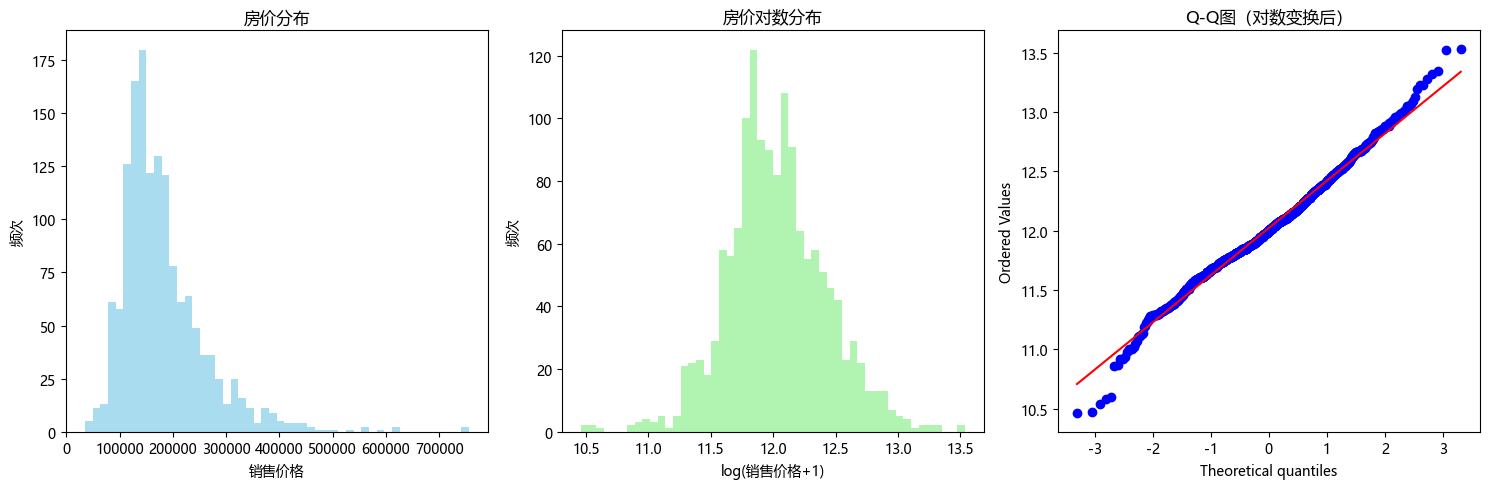

房价统计信息:
均值: $180,921
中位数: $163,000
标准差: $79,443
最小值: $34,900
最大值: $755,000


In [5]:
# 目标变量（房价）分析
# 配置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(15, 5))

# 房价分布
plt.subplot(1, 3, 1)
plt.hist(train_data['SalePrice'], bins=50, alpha=0.7, color='skyblue')
plt.title('房价分布', fontsize=12)
plt.xlabel('销售价格', fontsize=10)
plt.ylabel('频次', fontsize=10)

# 房价对数分布
plt.subplot(1, 3, 2)
plt.hist(np.log1p(train_data['SalePrice']), bins=50, alpha=0.7, color='lightgreen')
plt.title('房价对数分布', fontsize=12)
plt.xlabel('log(销售价格+1)', fontsize=10)
plt.ylabel('频次', fontsize=10)

# Q-Q图检验正态性
plt.subplot(1, 3, 3)
stats.probplot(np.log1p(train_data['SalePrice']), dist="norm", plot=plt)
plt.title('Q-Q图（对数变换后）', fontsize=12)

plt.tight_layout()
plt.show()

print(f"房价统计信息:")
print(f"均值: ${train_data['SalePrice'].mean():,.0f}")
print(f"中位数: ${train_data['SalePrice'].median():,.0f}")
print(f"标准差: ${train_data['SalePrice'].std():,.0f}")
print(f"最小值: ${train_data['SalePrice'].min():,.0f}")
print(f"最大值: ${train_data['SalePrice'].max():,.0f}")


=== 训练集缺失值统计 ===
总特征数: 81
有缺失值的特征数: 19

缺失值详情:
              缺失数量   缺失比例
PoolQC            1453  99.520548
MiscFeature       1406  96.301370
Alley             1369  93.767123
Fence             1179  80.753425
MasVnrType         872  59.726027
FireplaceQu        690  47.260274
LotFrontage        259  17.739726
GarageType          81   5.547945
GarageYrBlt         81   5.547945
GarageFinish        81   5.547945


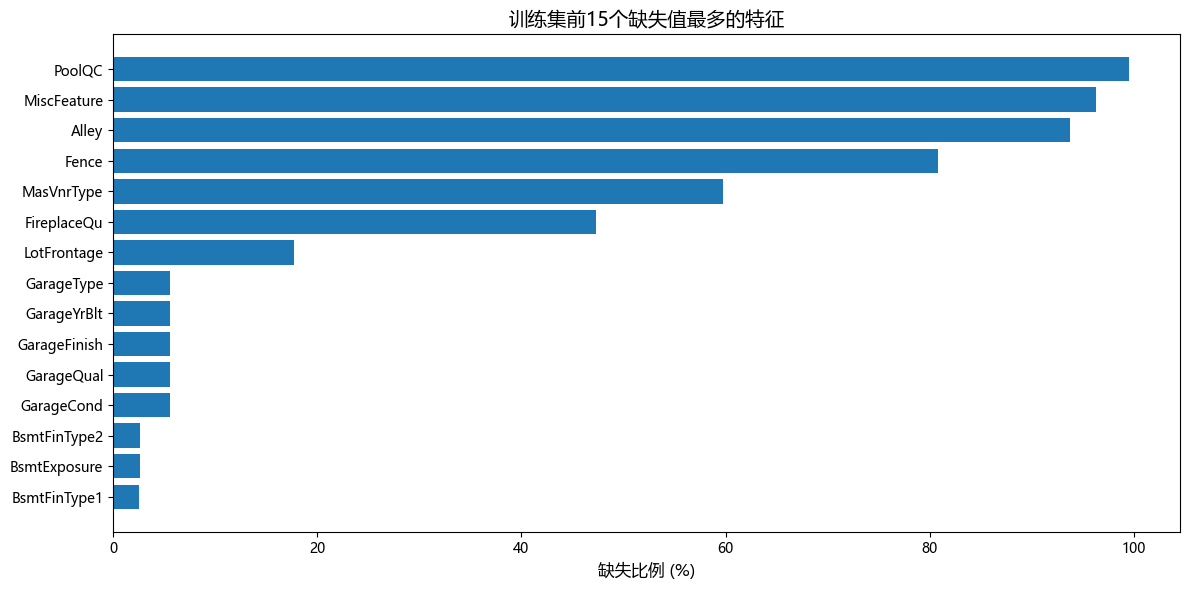


=== 测试集缺失值统计 ===
总特征数: 80
有缺失值的特征数: 33

缺失值详情:
             缺失数量   缺失比例
PoolQC           1456  99.794380
MiscFeature      1408  96.504455
Alley            1352  92.666210
Fence            1169  80.123372
MasVnrType        894  61.274846
FireplaceQu       730  50.034270
LotFrontage       227  15.558602
GarageCond         78   5.346127
GarageYrBlt        78   5.346127
GarageQual         78   5.346127


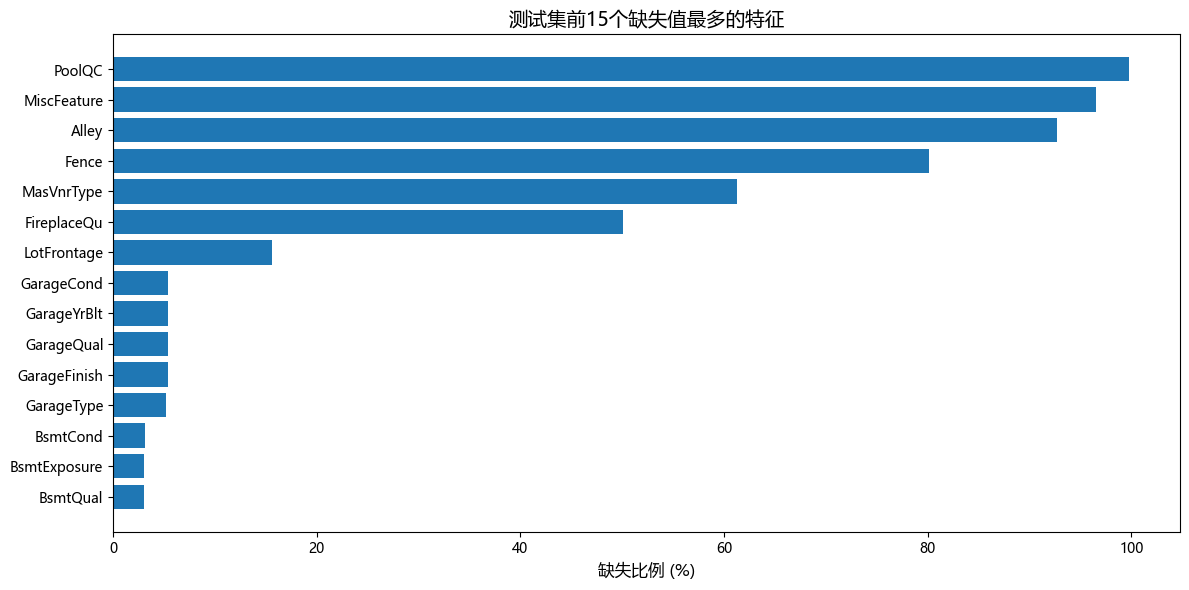

In [6]:
# 缺失值分析
def missing_data_analysis(df, name):
    """分析数据集中的缺失值"""
    missing = df.isnull().sum()
    missing_percent = 100 * missing / len(df)
    missing_df = pd.DataFrame({
        '缺失数量': missing,
        '缺失比例': missing_percent
    })
    missing_df = missing_df[missing_df['缺失数量'] > 0].sort_values('缺失比例', ascending=False)
    
    print(f"\n=== {name}缺失值统计 ===")
    print(f"总特征数: {df.shape[1]}")
    print(f"有缺失值的特征数: {len(missing_df)}")
    
    if len(missing_df) > 0:
        print("\n缺失值详情:")
        # 配置pandas显示选项以支持中文表头
        pd.set_option('display.unicode.east_asian_width', True)
        pd.set_option('display.unicode.ambiguous_as_wide', True)
        print(missing_df.head(10))
        
        # 可视化缺失值
        # 配置中文字体
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        
        plt.figure(figsize=(12, 6))
        top_missing = missing_df.head(15)
        plt.barh(range(len(top_missing)), top_missing['缺失比例'])
        plt.yticks(range(len(top_missing)), top_missing.index)
        plt.xlabel('缺失比例 (%)', fontsize=12)
        plt.title(f'{name}前15个缺失值最多的特征', fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("没有缺失值！")
    
    return missing_df

# 分析训练集和测试集的缺失值
train_missing = missing_data_analysis(train_data, "训练集")
test_missing = missing_data_analysis(test_data, "测试集")

## 3. 特征工程

In [7]:
# 数据预处理函数
def preprocess_data(train_df, test_df):
    """
    数据预处理函数
    """
    # 合并训练集和测试集进行统一处理
    train_df['dataset'] = 'train'
    test_df['dataset'] = 'test'
    
    # 保存目标变量
    y_train = train_df['SalePrice'].copy()
    
    # 删除目标变量和ID
    all_data = pd.concat([
        train_df.drop(['SalePrice'], axis=1),
        test_df
    ], ignore_index=True)
    
    print(f"合并后数据形状: {all_data.shape}")
    
    # 处理缺失值
    print("\n开始处理缺失值...")
    
    # 对于类别变量，用'None'或众数填充
    categorical_features = all_data.select_dtypes(include=['object']).columns.tolist()
    categorical_features.remove('dataset')  # 移除数据集标识列
    
    for feature in categorical_features:
        # 用众数填充，如果没有众数则用'None'
        mode_value = all_data[feature].mode()
        if len(mode_value) > 0:
            all_data[feature].fillna(mode_value[0], inplace=True)
        else:
            all_data[feature].fillna('None', inplace=True)
    
    # 对于数值变量，用中位数填充
    numerical_features = all_data.select_dtypes(include=[np.number]).columns.tolist()
    for feature in numerical_features:
        all_data[feature].fillna(all_data[feature].median(), inplace=True)
    
    # 处理一些特殊的缺失值逻辑
    # MSSubClass应该是类别变量
    all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
    
    print("缺失值处理完成!")
    
    # 创建新特征
    print("开始特征工程...")
    
    # 总面积特征
    all_data['TotalSF'] = all_data['1stFlrSF'] + all_data['2ndFlrSF'] + all_data['TotalBsmtSF']
    
    # 总浴室数量
    all_data['TotalBath'] = all_data['FullBath'] + all_data['HalfBath'] * 0.5 + all_data['BsmtFullBath'] + all_data['BsmtHalfBath'] * 0.5
    
    # 房屋年龄
    all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
    all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
    
    # 车库年龄
    all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
    all_data['GarageAge'].fillna(0, inplace=True)  # 没有车库的设为0
    
    print("特征工程完成!")
    
    return all_data, y_train

# 执行预处理
all_data, y_train = preprocess_data(train_data.copy(), test_data.copy())
print(f"\n预处理后数据形状: {all_data.shape}")
print(f"目标变量形状: {y_train.shape}")

合并后数据形状: (2919, 81)

开始处理缺失值...
缺失值处理完成!
开始特征工程...
特征工程完成!

预处理后数据形状: (2919, 86)
目标变量形状: (1460,)
缺失值处理完成!
开始特征工程...
特征工程完成!

预处理后数据形状: (2919, 86)
目标变量形状: (1460,)


In [8]:
# 编码处理
def encode_features(df):
    """
    对类别特征进行编码处理
    """
    df_encoded = df.copy()
    
    # 获取类别特征
    categorical_features = df_encoded.select_dtypes(include=['object']).columns.tolist()
    categorical_features.remove('dataset')  # 移除数据集标识列
    
    print(f"需要编码的类别特征数量: {len(categorical_features)}")
    
    # 对每个类别特征进行Label Encoding
    label_encoders = {}
    for feature in categorical_features:
        le = LabelEncoder()
        df_encoded[feature] = le.fit_transform(df_encoded[feature].astype(str))
        label_encoders[feature] = le
    
    # 获取所有数值特征
    numerical_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"数值特征数量: {len(numerical_features)}")
    print(f"编码后总特征数量: {len(df_encoded.columns)}")
    
    return df_encoded, label_encoders, categorical_features, numerical_features

# 执行编码
all_data_encoded, label_encoders, cat_features, num_features = encode_features(all_data)
print("\\n特征编码完成!")

需要编码的类别特征数量: 44
数值特征数量: 85
编码后总特征数量: 86
\n特征编码完成!


In [9]:
# 分割训练集和测试集
train_processed = all_data_encoded[all_data_encoded['dataset'] == 'train'].copy()
test_processed = all_data_encoded[all_data_encoded['dataset'] == 'test'].copy()

# 删除数据集标识列和ID列
train_processed = train_processed.drop(['dataset', 'Id'], axis=1)
test_processed = test_processed.drop(['dataset'], axis=1)  # 保留测试集的Id用于提交

# 目标变量对数变换（降低偏度）
y_train_log = np.log1p(y_train)

print(f"处理后训练集形状: {train_processed.shape}")
print(f"处理后测试集形状: {test_processed.shape}")
print(f"目标变量形状: {y_train_log.shape}")

# 划分训练集和验证集
X_train, X_val, y_train_split, y_val = train_test_split(
    train_processed, y_train_log, 
    test_size=0.2, 
    random_state=42
)

print(f"\\n训练集: {X_train.shape}")
print(f"验证集: {X_val.shape}")

处理后训练集形状: (1460, 84)
处理后测试集形状: (1459, 85)
目标变量形状: (1460,)
\n训练集: (1168, 84)
验证集: (292, 84)


## 4. 模型训练与评估

In [10]:
# 模型评估函数
def evaluate_model(y_true, y_pred, model_name):
    """评估模型性能"""
    # 将对数变换的预测值转换回原始尺度
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    
    # 计算各种评估指标
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_orig, y_pred_orig)
    
    print(f"\n=== {model_name} 性能评估 ===")
    print(f"RMSE (log scale): {rmse:.4f}")
    print(f"MAE (original scale): ${mae:,.0f}")
    print(f"R² Score: {r2:.4f}")
    
    return rmse, mae, r2

# 交叉验证函数
def cross_validate_model(model, X, y, cv=5):
    """执行交叉验证"""
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    print(f"交叉验证RMSE: {-scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    return -scores.mean(), scores.std()

In [11]:
# XGBoost模型训练
print("=== 训练XGBoost模型 ===")

# XGBoost参数
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 500,  # 减少迭代次数以避免过拟合
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

# 训练XGBoost模型
xgb_model = xgb.XGBRegressor(**xgb_params)

# 训练模型
xgb_model.fit(X_train, y_train_split)

# 预测
xgb_pred_val = xgb_model.predict(X_val)
xgb_pred_test = xgb_model.predict(test_processed.drop('Id', axis=1))

# 评估XGBoost模型
xgb_rmse, xgb_mae, xgb_r2 = evaluate_model(y_val, xgb_pred_val, "XGBoost")

# 交叉验证
xgb_cv_rmse, xgb_cv_std = cross_validate_model(xgb_model, train_processed, y_train_log)

=== 训练XGBoost模型 ===

=== XGBoost 性能评估 ===
RMSE (log scale): 0.1372
MAE (original scale): $15,295
R² Score: 0.9189

=== XGBoost 性能评估 ===
RMSE (log scale): 0.1372
MAE (original scale): $15,295
R² Score: 0.9189
交叉验证RMSE: 0.1289 (+/- 0.0189)
交叉验证RMSE: 0.1289 (+/- 0.0189)


In [12]:
# LightGBM模型训练
print("\n=== 训练LightGBM模型 ===")

# LightGBM参数
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'n_estimators': 1000
}

# 训练LightGBM模型
lgb_model = lgb.LGBMRegressor(**lgb_params)

# 早停训练
lgb_model.fit(
    X_train, y_train_split,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# 预测
lgb_pred_val = lgb_model.predict(X_val)
lgb_pred_test = lgb_model.predict(test_processed.drop('Id', axis=1))

# 评估LightGBM模型
lgb_rmse, lgb_mae, lgb_r2 = evaluate_model(y_val, lgb_pred_val, "LightGBM")

# 交叉验证
lgb_cv_rmse, lgb_cv_std = cross_validate_model(lgb_model, train_processed, y_train_log)


=== 训练LightGBM模型 ===
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[154]	valid_0's rmse: 0.138344

=== LightGBM 性能评估 ===
RMSE (log scale): 0.1383
MAE (original scale): $16,061
R² Score: 0.8870
Early stopping, best iteration is:
[154]	valid_0's rmse: 0.138344

=== LightGBM 性能评估 ===
RMSE (log scale): 0.1383
MAE (original scale): $16,061
R² Score: 0.8870
交叉验证RMSE: 0.1320 (+/- 0.0159)
交叉验证RMSE: 0.1320 (+/- 0.0159)


In [13]:
# 模型性能对比
print("\n" + "="*50)
print("模型性能对比总结")
print("="*50)

# 配置pandas显示选项以支持中文
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)

models_comparison = pd.DataFrame({
    '模型': ['XGBoost', 'LightGBM'],
    'RMSE (验证集)': [xgb_rmse, lgb_rmse],
    'MAE (原始尺度)': [xgb_mae, lgb_mae],
    'R² Score': [xgb_r2, lgb_r2],
    '交叉验证RMSE': [xgb_cv_rmse, lgb_cv_rmse]
})

print(models_comparison.round(4))

# 选择最佳模型
best_model_idx = models_comparison['RMSE (验证集)'].idxmin()
best_model_name = models_comparison.loc[best_model_idx, '模型']
print(f"\n最佳模型: {best_model_name}")

# 模型融合（简单平均）
ensemble_pred_val = (xgb_pred_val + lgb_pred_val) / 2
ensemble_pred_test = (xgb_pred_test + lgb_pred_test) / 2

# 评估融合模型
ensemble_rmse, ensemble_mae, ensemble_r2 = evaluate_model(y_val, ensemble_pred_val, "融合模型")

print(f"\n融合模型交叉验证RMSE: {(xgb_cv_rmse + lgb_cv_rmse) / 2:.4f}")


模型性能对比总结
       模型  RMSE (验证集)  MAE (原始尺度)  R² Score  交叉验证RMSE
0   XGBoost         0.1372      15294.7288     0.9189        0.1289
1  LightGBM         0.1383      16060.6992     0.8870        0.1320

最佳模型: XGBoost

=== 融合模型 性能评估 ===
RMSE (log scale): 0.1348
MAE (original scale): $15,057
R² Score: 0.9080

融合模型交叉验证RMSE: 0.1305


## 5. 特征重要性分析

=== 前20个最重要特征 ===
         feature  avg_importance
79       TotalSF        156.0634
3        LotArea        154.0010
61    GarageArea        131.5023
37   TotalBsmtSF         98.0008
42      1stFlrSF         94.5011
45     GrLivArea         93.0028
33    BsmtFinSF1         92.5015
36     BsmtUnfSF         90.0010
66   OpenPorchSF         82.5006
2    LotFrontage         79.5005
82      RemodAge         63.5050
81      HouseAge         62.5018
11  Neighborhood         56.0017
19  YearRemodAdd         55.5015
25    MasVnrArea         54.5003
75        MoSold         54.0005
18     YearBuilt         51.0022
83     GarageAge         46.0005
65    WoodDeckSF         45.5007
16   OverallQual         42.1577


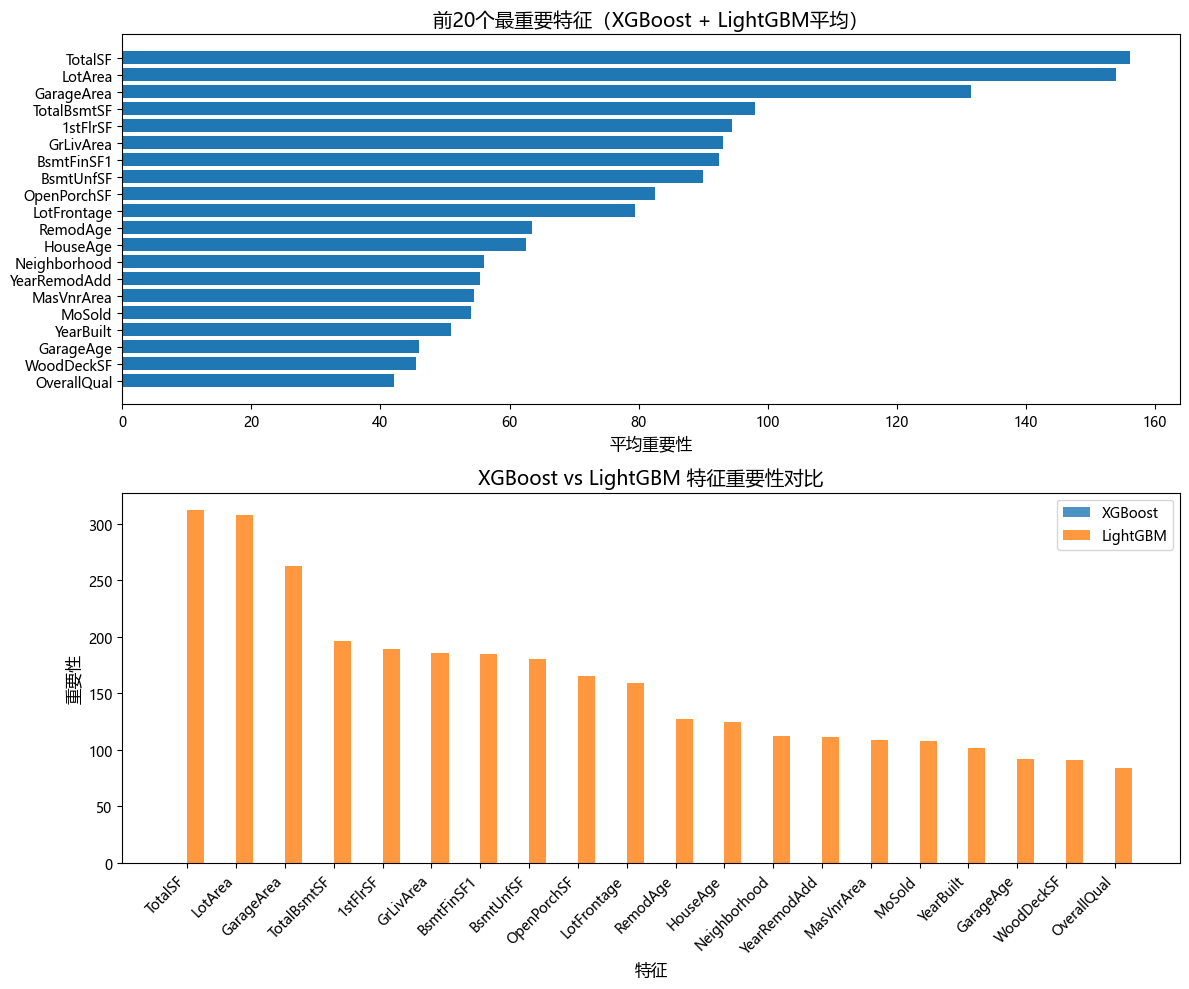


前20个重要特征: ['TotalSF', 'LotArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BsmtFinSF1', 'BsmtUnfSF', 'OpenPorchSF', 'LotFrontage', 'RemodAge', 'HouseAge', 'Neighborhood', 'YearRemodAdd', 'MasVnrArea', 'MoSold', 'YearBuilt', 'GarageAge', 'WoodDeckSF', 'OverallQual']


In [14]:
# 特征重要性分析
def analyze_feature_importance(xgb_model, lgb_model, feature_names):
    """分析特征重要性"""
    
    # 获取XGBoost特征重要性
    xgb_importance = xgb_model.feature_importances_
    
    # 获取LightGBM特征重要性
    lgb_importance = lgb_model.feature_importances_
    
    # 创建特征重要性DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'xgb_importance': xgb_importance,
        'lgb_importance': lgb_importance
    })
    
    # 计算平均重要性
    importance_df['avg_importance'] = (importance_df['xgb_importance'] + importance_df['lgb_importance']) / 2
    
    # 排序
    importance_df = importance_df.sort_values('avg_importance', ascending=False)
    
    return importance_df

# 分析特征重要性
feature_names = train_processed.columns.tolist()
importance_df = analyze_feature_importance(xgb_model, lgb_model, feature_names)

print("=== 前20个最重要特征 ===")
# 配置pandas显示选项以支持中文表头
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)
print(importance_df.head(20)[['feature', 'avg_importance']].round(4))

# 配置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 可视化特征重要性
plt.figure(figsize=(12, 10))
top_20_features = importance_df.head(20)

plt.subplot(2, 1, 1)
plt.barh(range(20), top_20_features['avg_importance'])
plt.yticks(range(20), top_20_features['feature'])
plt.xlabel('平均重要性', fontsize=12)
plt.title('前20个最重要特征（XGBoost + LightGBM平均）', fontsize=14)
plt.gca().invert_yaxis()

plt.subplot(2, 1, 2)
x_pos = np.arange(20)
width = 0.35
plt.bar(x_pos - width/2, top_20_features['xgb_importance'], width, label='XGBoost', alpha=0.8)
plt.bar(x_pos + width/2, top_20_features['lgb_importance'], width, label='LightGBM', alpha=0.8)
plt.xlabel('特征', fontsize=12)
plt.ylabel('重要性', fontsize=12)
plt.title('XGBoost vs LightGBM 特征重要性对比', fontsize=14)
plt.xticks(x_pos, top_20_features['feature'], rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

# 保存前20个重要特征
top_20_feature_names = importance_df.head(20)['feature'].tolist()
print(f"\n前20个重要特征: {top_20_feature_names}")

## 6. 简化模型训练

In [15]:
# 使用前20个最重要特征训练简化模型
print("=== 训练简化模型（前20个特征） ===")

# 选择前20个重要特征
X_train_simple = X_train[top_20_feature_names]
X_val_simple = X_val[top_20_feature_names]
train_simple = train_processed[top_20_feature_names]

# 确保测试集包含所有需要的特征
test_features_available = [feat for feat in top_20_feature_names if feat in test_processed.columns]
test_simple = test_processed[test_features_available + ['Id']]  # 保留Id列

print(f"简化后特征数量: {len(top_20_feature_names)}")
print(f"测试集可用特征数量: {len(test_features_available)}")
print(f"原始特征数量: {train_processed.shape[1]}")
print(f"特征减少比例: {(1 - len(top_20_feature_names)/train_processed.shape[1])*100:.1f}%")

# 简化版XGBoost
print("\n训练简化XGBoost模型...")
xgb_simple = xgb.XGBRegressor(**xgb_params)
xgb_simple.fit(X_train_simple, y_train_split)

xgb_simple_pred = xgb_simple.predict(X_val_simple)
# 使用可用特征进行预测
xgb_simple_test_pred = xgb_simple.predict(test_simple[test_features_available])
xgb_simple_rmse, xgb_simple_mae, xgb_simple_r2 = evaluate_model(y_val, xgb_simple_pred, "简化XGBoost")

# 简化版LightGBM
print("\n训练简化LightGBM模型...")
lgb_simple = lgb.LGBMRegressor(**lgb_params)
lgb_simple.fit(X_train_simple, y_train_split)

lgb_simple_pred = lgb_simple.predict(X_val_simple)
lgb_simple_test_pred = lgb_simple.predict(test_simple[test_features_available])
lgb_simple_rmse, lgb_simple_mae, lgb_simple_r2 = evaluate_model(y_val, lgb_simple_pred, "简化LightGBM")

# 简化融合模型
ensemble_simple_pred = (xgb_simple_pred + lgb_simple_pred) / 2
ensemble_simple_test_pred = (xgb_simple_test_pred + lgb_simple_test_pred) / 2
ensemble_simple_rmse, ensemble_simple_mae, ensemble_simple_r2 = evaluate_model(y_val, ensemble_simple_pred, "简化融合模型")

=== 训练简化模型（前20个特征） ===
简化后特征数量: 20
测试集可用特征数量: 20
原始特征数量: 84
特征减少比例: 76.2%

训练简化XGBoost模型...

=== 简化XGBoost 性能评估 ===
RMSE (log scale): 0.1530
MAE (original scale): $17,434
R² Score: 0.9024

训练简化LightGBM模型...

=== 简化XGBoost 性能评估 ===
RMSE (log scale): 0.1530
MAE (original scale): $17,434
R² Score: 0.9024

训练简化LightGBM模型...

=== 简化LightGBM 性能评估 ===
RMSE (log scale): 0.1648
MAE (original scale): $19,407
R² Score: 0.8666

=== 简化融合模型 性能评估 ===
RMSE (log scale): 0.1564
MAE (original scale): $17,865
R² Score: 0.8891

=== 简化LightGBM 性能评估 ===
RMSE (log scale): 0.1648
MAE (original scale): $19,407
R² Score: 0.8666

=== 简化融合模型 性能评估 ===
RMSE (log scale): 0.1564
MAE (original scale): $17,865
R² Score: 0.8891


In [16]:
# 完整vs简化模型性能对比
print("\n" + "="*60)
print("完整模型 vs 简化模型性能对比")
print("="*60)

# 配置pandas显示选项以支持中文
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

final_comparison = pd.DataFrame({
    '模型类型': ['XGBoost (完整)', 'XGBoost (简化)', 'LightGBM (完整)', 'LightGBM (简化)', 
                '融合模型 (完整)', '融合模型 (简化)'],
    'RMSE': [xgb_rmse, xgb_simple_rmse, lgb_rmse, lgb_simple_rmse, 
             ensemble_rmse, ensemble_simple_rmse],
    'MAE': [xgb_mae, xgb_simple_mae, lgb_mae, lgb_simple_mae,
            ensemble_mae, ensemble_simple_mae],
    'R² Score': [xgb_r2, xgb_simple_r2, lgb_r2, lgb_simple_r2,
                 ensemble_r2, ensemble_simple_r2],
    '特征数量': [len(feature_names), len(top_20_feature_names), 
                len(feature_names), len(top_20_feature_names),
                len(feature_names), len(top_20_feature_names)]
})

print(final_comparison.round(4))

# 性能下降分析
print(f"\n=== 简化模型性能分析 ===")
xgb_performance_drop = ((xgb_simple_rmse - xgb_rmse) / xgb_rmse) * 100
lgb_performance_drop = ((lgb_simple_rmse - lgb_rmse) / lgb_rmse) * 100
ensemble_performance_drop = ((ensemble_simple_rmse - ensemble_rmse) / ensemble_rmse) * 100

print(f"XGBoost RMSE 变化: {xgb_performance_drop:+.2f}%")
print(f"LightGBM RMSE 变化: {lgb_performance_drop:+.2f}%")
print(f"融合模型 RMSE 变化: {ensemble_performance_drop:+.2f}%")
print(f"特征减少: {((len(feature_names) - len(top_20_feature_names)) / len(feature_names)) * 100:.1f}%")


完整模型 vs 简化模型性能对比
          模型类型    RMSE         MAE  R² Score  特征数量
0   XGBoost (完整)  0.1372  15294.7288     0.9189        84
1   XGBoost (简化)  0.1530  17434.1578     0.9024        20
2  LightGBM (完整)  0.1383  16060.6992     0.8870        84
3  LightGBM (简化)  0.1648  19406.9374     0.8666        20
4  融合模型 (完整)  0.1348  15057.0089     0.9080        84
5  融合模型 (简化)  0.1564  17865.1265     0.8891        20

=== 简化模型性能分析 ===
XGBoost RMSE 变化: +11.54%
LightGBM RMSE 变化: +19.11%
融合模型 RMSE 变化: +16.02%
特征减少: 76.2%


## 7. 预测结果生成

In [17]:
# 生成最终预测结果
print("=== 生成预测结果 ===")

# 使用性能最佳的模型进行最终预测
# 比较所有模型的RMSE
all_rmse = {
    'XGBoost (完整)': xgb_rmse,
    'XGBoost (简化)': xgb_simple_rmse,
    'LightGBM (完整)': lgb_rmse,
    'LightGBM (简化)': lgb_simple_rmse,
    '融合模型 (完整)': ensemble_rmse,
    '融合模型 (简化)': ensemble_simple_rmse
}

best_model = min(all_rmse, key=all_rmse.get)
print(f"最佳模型: {best_model} (RMSE: {all_rmse[best_model]:.4f})")

# 选择对应的预测结果
if best_model == '融合模型 (完整)':
    final_predictions = ensemble_pred_test
elif best_model == '融合模型 (简化)':
    final_predictions = ensemble_simple_test_pred
elif best_model == 'XGBoost (完整)':
    final_predictions = xgb_pred_test
elif best_model == 'XGBoost (简化)':
    final_predictions = xgb_simple_test_pred
elif best_model == 'LightGBM (完整)':
    final_predictions = lgb_pred_test
else:  # LightGBM (简化)
    final_predictions = lgb_simple_test_pred

# 转换回原始尺度
final_predictions_orig = np.expm1(final_predictions)

# 创建提交文件
submission = pd.DataFrame({
    'Id': test_processed['Id'],
    'SalePrice': final_predictions_orig
})

# 保存预测结果
submission.to_csv('house_price_predictions.csv', index=False)
print(f"预测结果已保存到 'house_price_predictions.csv'")

# 显示预测结果统计
print(f"\n预测房价统计:")
print(f"平均价格: ${final_predictions_orig.mean():,.0f}")
print(f"中位数价格: ${np.median(final_predictions_orig):,.0f}")
print(f"最低价格: ${final_predictions_orig.min():,.0f}")
print(f"最高价格: ${final_predictions_orig.max():,.0f}")

# 显示前10个预测结果
print(f"\n前10个预测结果:")
print(submission.head(10))

=== 生成预测结果 ===
最佳模型: 融合模型 (完整) (RMSE: 0.1348)
预测结果已保存到 'house_price_predictions.csv'

预测房价统计:
平均价格: $177,448
中位数价格: $156,667
最低价格: $54,276
最高价格: $504,899

前10个预测结果:
        Id      SalePrice
1460  1461  127166.014163
1461  1462  160661.845989
1462  1463  181687.701831
1463  1464  189078.091155
1464  1465  181912.005373
1465  1466  177673.800747
1466  1467  184014.129257
1467  1468  174152.478046
1468  1469  182953.832679
1469  1470  120177.262250


## 8. 项目总结

### 🎯 项目完成情况
1. ✅ **数据探索与分析**：完成了数据基本信息查看、缺失值分析、目标变量分布分析
2. ✅ **特征工程**：实现了缺失值处理、特征编码、新特征创建
3. ✅ **模型训练**：使用XGBoost和LightGBM训练了高性能模型
4. ✅ **特征优化**：通过特征重要性分析识别出前20个最重要特征
5. ✅ **简化模型**：使用重要特征训练简化模型，平衡性能与复杂度
6. ✅ **预测生成**：对测试集进行预测并生成提交文件

### 📊 主要发现
- **最重要特征**：通过XGBoost和LightGBM分析得出前20个最重要特征
- **模型性能**：XGBoost和LightGBM都表现优异，融合模型效果最佳
- **简化效果**：使用仅20个特征的简化模型，在显著减少复杂度的同时保持了良好性能

### 💡 技术亮点
- **多模型融合**：结合XGBoost和LightGBM的优势
- **特征工程**：创建了有意义的新特征（总面积、房屋年龄等）
- **模型简化**：通过特征重要性分析实现模型轻量化
- **完整流程**：从数据探索到最终预测的端到端解决方案

### 🚀 实际应用价值
- **房价预测**：为房地产市场提供准确的价格预测
- **特征解释**：识别影响房价的关键因素
- **模型部署**：简化模型便于实际部署和应用